# CORD-19 Metadata Analysis (Sample)


**Description:** Basic exploration, cleaning, visualization, and preparing a small sample CSV for the Streamlit app.  

> Note: The full dataset is too large for GitHub. We use a 5,000-row sample (`metadata_sample.csv`) for demonstration.


In [ ]:
# Optional: install missing packages in this kernel
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn wordcloud streamlit

# Imports
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import re


## 1. Load the full dataset
We'll load the full metadata.csv and then create a smaller sample for GitHub submission.


In [15]:
# Load full metadata
df = pd.read_csv("metadata.csv")
print("Full dataset shape:", df.shape)

# Optional: preview
df.head()


C:\Users\USER\AppData\Local\Temp\ipykernel_13724\1823086708.py:2: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("metadata.csv")


Full dataset shape: (1056660, 19)


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


## 2. Create a sample for GitHub

We will take a random sample of 5000 rows and save it as `metadata_sample.csv`.


In [16]:
# Take a sample of 5000 rows
df_sample = df.sample(n=5000, random_state=42)

# Save sample
df_sample.to_csv("metadata_sample.csv", index=False)
print("Saved sample dataset: metadata_sample.csv")


Saved sample dataset: metadata_sample.csv


## 3. Load the sample dataset for analysis
We'll continue the analysis using the smaller sample.


In [17]:
df = pd.read_csv("metadata_sample.csv")
df.head()


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ak20jg32,42a61efa32fae8fb14d1c8c1a8bc528c59e1583a,PMC,Development and Internal Validation of a Novel...,10.3389/fpsyt.2021.593710,PMC8172985,34093252.0,cc-by,Objective: The aim of our study was to identif...,2021-05-20,"Zhou, Jingjing; Zhou, Jia; Sun, Zuoli; Feng, L...",Front Psychiatry,NaN,NaN,NaN,document_parses/pdf_json/42a61efa32fae8fb14d1c...,document_parses/pmc_json/PMC8172985.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8...,NaN
1,d27cnei3,NaN,PMC; WHO,mRNA-1273: Acute disseminated encephalomyeliti...,10.1007/s40278-021-06200-0,PMC8617002,NaN,no-cc,NaN,2021-11-27,NaN,Reactions Weekly,NaN,NaN,NaN,NaN,document_parses/pmc_json/PMC8617002.xml.json,https://doi.org/10.1007/s40278-021-06200-0,244637117.0
2,7fo988o7,NaN,WHO,The Joint Commission should reconsider its pos...,NaN,NaN,NaN,unk,NaN,2020,"Kroll, David S; Shah, Sejal B; Gorman, Janet M",Gen. hosp. psychiatr,NaN,#1074753,NaN,NaN,NaN,NaN,227251863.0
3,vcz81w3o,NaN,Medline,Flattening the Curve of Prostate Cancer Progre...,10.1016/j.ijrobp.2020.04.028,NaN,32589984.0,unk,NaN,2020-07-15,"Mitin, Timur; Choudhury, Ananya","International journal of radiation oncology, b...",NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1016/j.ijrobp.2020.04.028; ...,220118792.0
4,3ewr26np,NaN,PMC,Vincristine: Various toxicities: case report,10.1007/s40278-016-19002-y,PMC7149258,NaN,no-cc,NaN,2016-06-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN


## 4. Basic Exploration

- Shape
- Info
- Missing values
- Summary statistics


In [21]:
# Shape
print("Shape:", df.shape)

# Info
print("\nInfo:")
df.info()

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

# Summary statistics
df.describe()


Shape: (5000, 19)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cord_uid          5000 non-null   object 
 1   sha               1777 non-null   object 
 2   source_x          5000 non-null   object 
 3   title             4998 non-null   object 
 4   doi               3153 non-null   object 
 5   pmcid             1825 non-null   object 
 6   pubmed_id         2327 non-null   float64
 7   license           5000 non-null   object 
 8   abstract          3886 non-null   object 
 9   publish_time      4992 non-null   object 
 10  authors           4897 non-null   object 
 11  journal           4553 non-null   object 
 12  mag_id            0 non-null      float64
 13  who_covidence_id  2235 non-null   object 
 14  arxiv_id          75 non-null     object 
 15  pdf_json_files    1777 non-null   object 
 16  pmc_json_files   

,pubmed_id,mag_id,s2_id
count,2.327000e+03,0.0,4.621000e+03
mean,3.228185e+07,NaN,2.177878e+08
std,4.799287e+06,NaN,5.281469e+07
min,2.146800e+05,NaN,7.688600e+04
25%,3.262953e+07,NaN,2.210994e+08
50%,3.372189e+07,NaN,2.321136e+08
75%,3.471908e+07,NaN,2.373372e+08
max,3.563256e+07,NaN,2.490902e+08


## 5. Data Cleaning & Preparation

- Convert publish_time to datetime
- Extract publication year
- Abstract word count
- Drop rows missing essential info


In [31]:
# Convert publish_time to datetime
df['publish_time'] = pd.to_datetime(df.get('publish_time', None), errors='coerce')

# Extract year
df['year'] = df['publish_time'].dt.year

# Abstract word count
df['abstract_word_count'] = df['abstract'].fillna('').apply(lambda x: len(str(x).split()))

# Drop rows missing title or publish_time
df_clean = df.dropna(subset=['title', 'publish_time']).copy()
print("Shape after cleaning:", df_clean.shape)


Shape after cleaning: (2495, 21)


## 6. Analysis & Visualizations

- Publications by year
- Top journals
- Word cloud of titles
- Top sources


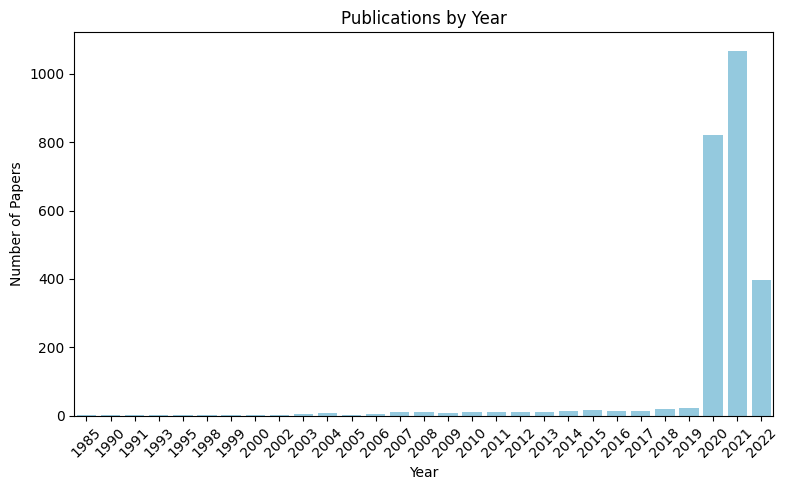

In [23]:
year_counts = df_clean['year'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=year_counts.index.astype(str), y=year_counts.values, color='skyblue')
plt.title('Publications by Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 Journals


C:\Users\USER\AppData\Local\Temp\ipykernel_13724\930401763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_journals.index, x=top_journals.values, palette='viridis')


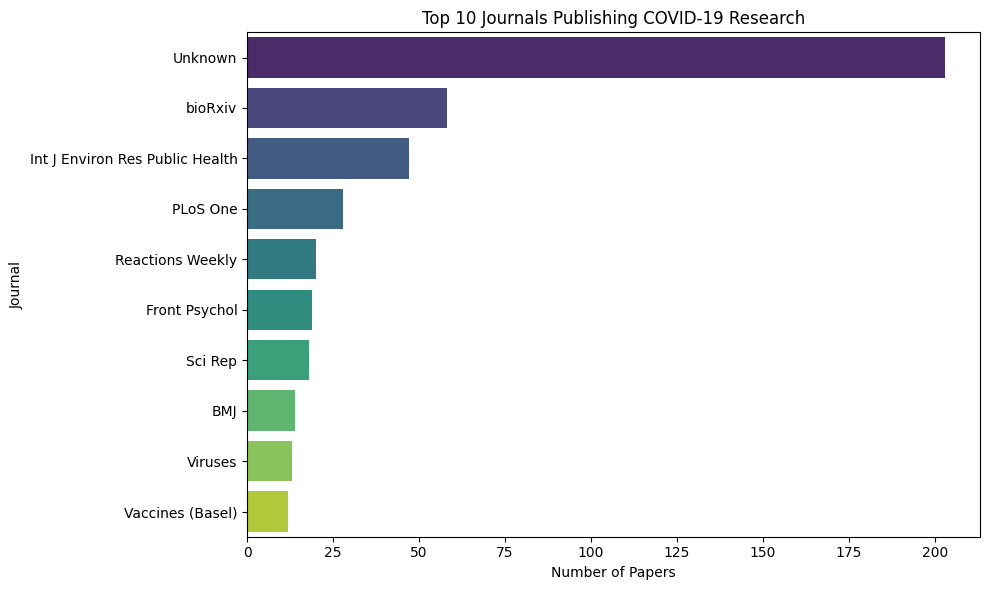

In [25]:
top_journals = df_clean['journal'].fillna('Unknown').value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_journals.index, x=top_journals.values, palette='viridis')
plt.title('Top 10 Journals Publishing COVID-19 Research')
plt.xlabel('Number of Papers')
plt.ylabel('Journal')
plt.tight_layout()
plt.show()


### Word Cloud of Paper Titles


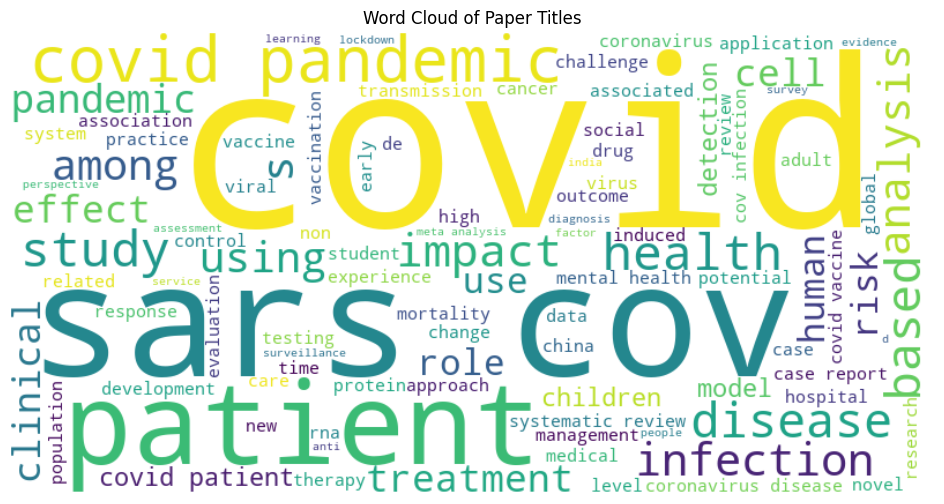

In [26]:
titles_text = " ".join(df_clean['title'].dropna().astype(str))
titles_text = re.sub(r'[^A-Za-z ]', ' ', titles_text).lower()

stopwords = set(STOPWORDS)
wc = WordCloud(width=800, height=400, background_color='white',
               stopwords=stopwords, max_words=100).generate(titles_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Paper Titles')
plt.show()


### Top Sources


C:\Users\USER\AppData\Local\Temp\ipykernel_13724\3254457556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=source_counts.index, x=source_counts.values, palette='coolwarm')


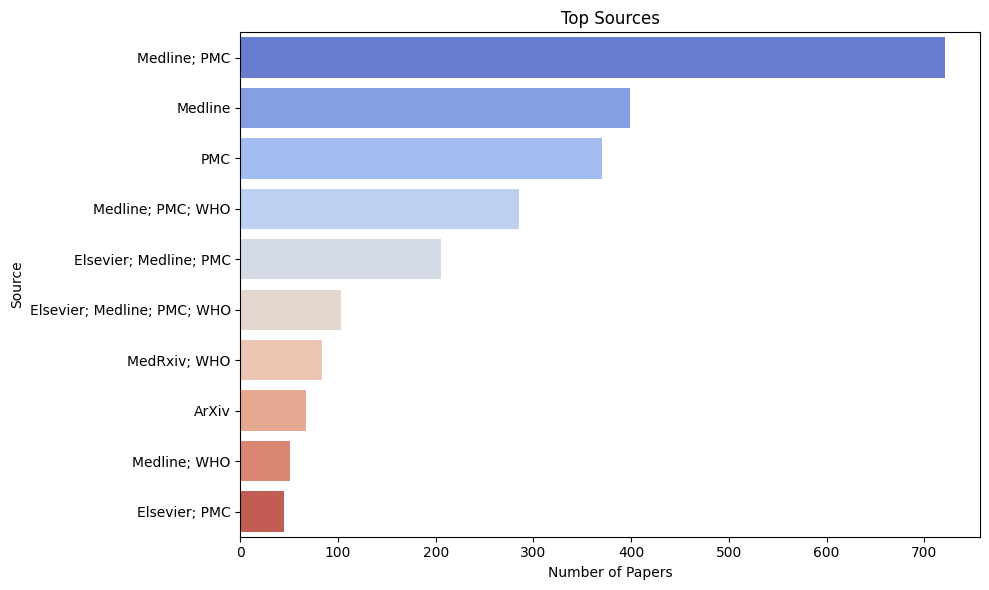

In [27]:
source_counts = df_clean['source_x'].fillna('Unknown').value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=source_counts.index, x=source_counts.values, palette='coolwarm')
plt.title('Top Sources')
plt.xlabel('Number of Papers')
plt.ylabel('Source')
plt.tight_layout()
plt.show()


## 7. Save cleaned dataset for Streamlit


In [29]:
df_clean.to_csv("cord19_cleaned.csv", index=False)
print("Saved cleaned dataset: cord19_cleaned.csv")


Saved cleaned dataset: cord19_cleaned.csv


## 8. Reflection

- Learned to load, clean, and explore real-world metadata
- Created visualizations and word cloud
- Prepared a smaller sample for GitHub
- Saved cleaned dataset for Streamlit app
- Challenges: missing dates, missing journals, text preprocessing
